# WD-cGAN — Modulo 1: Download ITACA v4.0

Range selezionato: **Mw [5.0, 5.5)** — tutti i record disponibili (~1913)

Passi:
1. Legge dati.csv, filtra Mw [5.0,5.5), deduplica per (evento, stazione)
2. Scarica ZIP da itaca40ws, estrae HGE/HGN/HGZ
3. Normalizzazione z-score: x_hat = (x - mu) / sigma  (Eq.1 paper)
4. Resample a fs=200 Hz, pad/trim a N=8000 campioni (40s)
5. Salva HDF5


In [ ]:
!pip install -q requests h5py numpy scipy pandas tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE_DIR  = '/content/drive/MyDrive/WDcGAN'
DATA_DIR  = os.path.join(BASE_DIR, 'data')
RAW_DIR   = os.path.join(DATA_DIR, 'raw_zip')
HDF5_PATH = os.path.join(DATA_DIR, 'itaca_dataset.h5')
CSV_PATH  = os.path.join(DATA_DIR, 'dati.csv')

os.makedirs(RAW_DIR, exist_ok=True)
print('Drive OK')
print('CSV:', os.path.exists(CSV_PATH))

In [ ]:
import pandas as pd
import numpy as np

# ── Parametri ─────────────────────────────────────────────────────────────────
MW_MIN     = 5.0
MW_MAX     = 5.5
FS_TARGET  = 200          # Hz — paper Sezione 3.1
DURATION_S = 40           # secondi
N_SAMPLES  = FS_TARGET * DURATION_S  # 8000 campioni

# ── Carica e filtra CSV ────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)
df['mw'] = pd.to_numeric(df['mw'], errors='coerce')
df = df.dropna(subset=['mw', 'esm_event_id', 'station_code'])
df = df.drop_duplicates(subset=['esm_event_id', 'station_code'])

# Filtro fascia Mw [5.0, 5.5)
mask = (df['mw'] >= MW_MIN) & (df['mw'] < MW_MAX)
df_sel = df[mask].reset_index(drop=True)

print(f'Record totali CSV: {len(df)}')
print(f'Record Mw [{MW_MIN},{MW_MAX}): {len(df_sel)}')
print(f'Range Mw selezionato: {df_sel.mw.min():.2f} — {df_sel.mw.max():.2f}')
print(f'Campioni per segnale: {N_SAMPLES} ({DURATION_S}s a {FS_TARGET}Hz)')

In [ ]:
import requests, zipfile, time
from scipy.signal import resample_poly
from math import gcd

ITACA_WS   = 'https://itaca.mi.ingv.it/itaca40ws/eventdata/1/query'
COMPONENTS = {
    'E': ['HGE', 'HNE', 'HLE'],
    'N': ['HGN', 'HNN', 'HLN'],
    'Z': ['HGZ', 'HNZ', 'HLZ'],
}

def find_component(namelist, codes):
    for name in namelist:
        for c in codes:
            if c in name.upper():
                return name
    return None

def parse_asc(content_bytes):
    lines = content_bytes.decode('utf-8', errors='replace').splitlines()
    dt = None
    data_start = 0
    for i, line in enumerate(lines):
        ls = line.strip()
        if 'DT' in line.upper() or 'SAMPLING' in line.upper():
            for p in ls.split():
                try:
                    v = float(p)
                    if 0.001 < v < 1.0:
                        dt = v; break
                except: pass
        try:
            float(ls.split()[0] if ls else 'x')
            data_start = i; break
        except: pass
    values = []
    for line in lines[data_start:]:
        for token in line.strip().split():
            try: values.append(float(token))
            except: pass
    if not values:
        return None, None
    fs = round(1.0 / dt) if dt and dt > 0 else FS_TARGET
    return np.array(values, dtype=np.float32), int(fs)

def preprocess(signal, fs_orig):
    """
    Eq.1 paper: normalizzazione z-score per componente
    x_hat = (x - mean) / std
    Poi resample a FS_TARGET e pad/trim a N_SAMPLES.
    """
    if signal is None or len(signal) < 200:
        return None
    # Resample
    if abs(fs_orig - FS_TARGET) > 1:
        g = gcd(FS_TARGET, max(fs_orig, 1))
        try:
            signal = resample_poly(signal, FS_TARGET//g, fs_orig//g).astype(np.float32)
        except:
            return None
    # Pad / trim a N_SAMPLES
    if len(signal) >= N_SAMPLES:
        signal = signal[:N_SAMPLES]
    else:
        signal = np.pad(signal, (0, N_SAMPLES - len(signal)))
    # Z-score (Eq.1 paper)
    mu, sigma = signal.mean(), signal.std()
    if sigma < 1e-10:
        return None
    return ((signal - mu) / sigma).astype(np.float32)

def download_record(ev_id, st_id):
    zip_path = os.path.join(RAW_DIR, f'{ev_id}_{st_id}.zip')
    if not os.path.exists(zip_path):
        try:
            r = requests.get(ITACA_WS,
                params={'eventid': ev_id, 'station': st_id, 'format': 'ascii'},
                timeout=60)
            r.raise_for_status()
            with open(zip_path, 'wb') as f:
                f.write(r.content)
            time.sleep(0.3)
        except:
            return None
    try:
        with zipfile.ZipFile(zip_path) as zf:
            nl = zf.namelist()
            sigs = {}
            for comp, codes in COMPONENTS.items():
                fname = find_component(nl, codes)
                if fname is None:
                    continue
                raw, fs_orig = parse_asc(zf.read(fname))
                proc = preprocess(raw, fs_orig)
                if proc is not None:
                    sigs[comp] = proc
            return sigs if len(sigs) == 3 else None
    except:
        return None

print('Funzioni download OK')

In [ ]:
import h5py
from tqdm.notebook import tqdm

records = []
failed  = 0

print(f'Download {len(df_sel)} record Mw [{MW_MIN},{MW_MAX})...')

for _, row in tqdm(df_sel.iterrows(), total=len(df_sel)):
    ev_id = str(row['esm_event_id']).strip()
    st_id = str(row['station_code']).strip()
    mw    = float(row['mw'])

    sigs = download_record(ev_id, st_id)
    if sigs is None:
        failed += 1
        continue

    records.append({
        'sig_e': sigs['E'], 'sig_n': sigs['N'], 'sig_z': sigs['Z'],
        'mw':    mw,
        'epi_dist': float(row['epi_dist']) if pd.notna(row.get('epi_dist')) else -1.0,
        'depth_km': float(row['ev_depth_km']) if pd.notna(row.get('ev_depth_km')) else -1.0,
        'event_id': ev_id, 'station': st_id
    })

print(f'\nScaricati: {len(records)} | Falliti: {failed}')
print(f'Range Mw effettivo: {min(r["mw"] for r in records):.2f} — {max(r["mw"] for r in records):.2f}')

In [ ]:
# ── Salva HDF5 ────────────────────────────────────────────────────────────────
assert len(records) > 0, 'Nessun record scaricato'
n = len(records)

with h5py.File(HDF5_PATH, 'w') as hf:
    hf.create_dataset('signals_e',  data=np.stack([r['sig_e'] for r in records]), compression='gzip')
    hf.create_dataset('signals_n',  data=np.stack([r['sig_n'] for r in records]), compression='gzip')
    hf.create_dataset('signals_z',  data=np.stack([r['sig_z'] for r in records]), compression='gzip')
    hf.create_dataset('magnitudes', data=np.array([r['mw']       for r in records], dtype=np.float32))
    hf.create_dataset('epi_dist',   data=np.array([r['epi_dist'] for r in records], dtype=np.float32))
    hf.create_dataset('depth_km',   data=np.array([r['depth_km'] for r in records], dtype=np.float32))
    hf.create_dataset('event_ids',  data=np.array([r['event_id'] for r in records], dtype='S50'))
    hf.create_dataset('stations',   data=np.array([r['station']  for r in records], dtype='S20'))
    hf.attrs['n_samples']     = N_SAMPLES
    hf.attrs['fs']            = FS_TARGET
    hf.attrs['mw_min']        = MW_MIN
    hf.attrs['mw_max']        = MW_MAX
    hf.attrs['total_records'] = n
    hf.attrs['duration_s']    = DURATION_S

print(f'HDF5 salvato: {n} record, shape ({n}, {N_SAMPLES})')

In [ ]:
# ── Verifica visiva ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

with h5py.File(HDF5_PATH, 'r') as hf:
    mags = hf['magnitudes'][:]
    sigs = hf['signals_e'][:6]

t = np.linspace(0, DURATION_S, N_SAMPLES)
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for ax, sig, mw in zip(axes.flatten(), sigs, mags[:6]):
    ax.plot(t, sig, linewidth=0.5, color='steelblue')
    ax.set_title(f'Mw={mw:.2f}')
    ax.set_xlabel('Tempo (s)'); ax.set_ylabel('Acc. norm.')
    ax.grid(alpha=0.3)

plt.suptitle(f'Esempi accelerogrammi HGE — Mw [{MW_MIN},{MW_MAX})')
plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'esempi_segnali.png'), dpi=150)
plt.show()

print(f'\nDataset pronto: {len(mags)} record')
print(f'Mw: {mags.min():.2f} — {mags.max():.2f}  media={mags.mean():.2f}')

Segnali totali:        1913
Onset > 35.0s (troncati): 34
Segnali validi:        1879


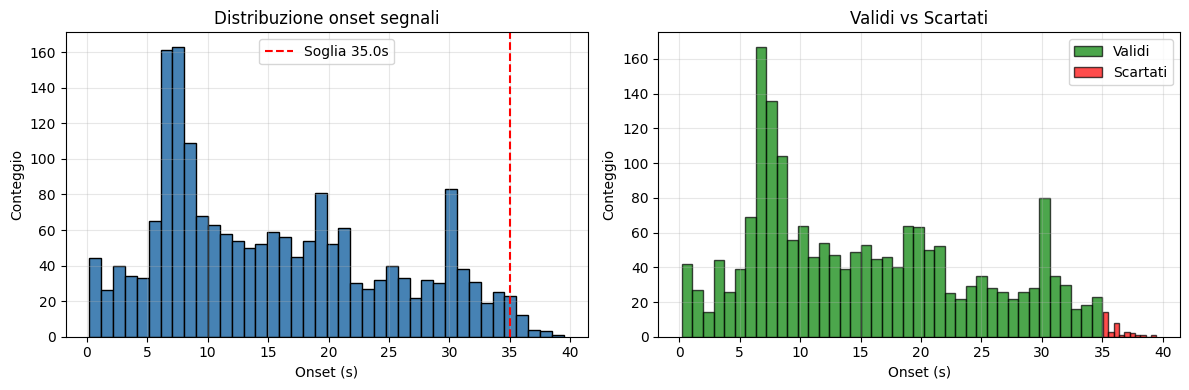


HDF5 aggiornato: 1879 record validi
Mw: 5.00 — 5.47  media=5.13


In [9]:
# ── Pulizia: rimuovi segnali con onset tardivo (troncati) ────────────────────
# Segnali con onset > 35s vengono troncati dalla finestra di 40s
# e non contengono la coda sismica completa — non adatti al training.

import h5py
import numpy as np
import matplotlib.pyplot as plt

def onset_time(sig, fs=200, threshold=0.05):
    """
    Stima posizione onset: primo campione con ampiezza > 5% del massimo.
    Restituisce il tempo in secondi.
    """
    thr = threshold * np.max(np.abs(sig))
    idx = np.where(np.abs(sig) > thr)[0]
    return idx[0] / fs if len(idx) > 0 else 40.0

ONSET_MAX_S = 35.0   # onset oltre 35s = segnale troncato

with h5py.File(HDF5_PATH, 'r') as hf:
    sigs_e = hf['signals_e'][:]
    sigs_n = hf['signals_n'][:]
    sigs_z = hf['signals_z'][:]
    mags   = hf['magnitudes'][:]
    epid   = hf['epi_dist'][:]
    depk   = hf['depth_km'][:]
    evids  = hf['event_ids'][:]
    stats  = hf['stations'][:]

onsets = np.array([onset_time(s) for s in sigs_e])
mask   = onsets < ONSET_MAX_S

print(f'Segnali totali:        {len(sigs_e)}')
print(f'Onset > {ONSET_MAX_S}s (troncati): {(~mask).sum()}')
print(f'Segnali validi:        {mask.sum()}')

# Istogramma onset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(onsets, bins=40, edgecolor='black', color='steelblue')
axes[0].axvline(ONSET_MAX_S, color='red', linestyle='--', label=f'Soglia {ONSET_MAX_S}s')
axes[0].set_xlabel('Onset (s)'); axes[0].set_ylabel('Conteggio')
axes[0].set_title('Distribuzione onset segnali'); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(onsets[mask], bins=40, edgecolor='black', color='green', alpha=0.7, label='Validi')
axes[1].hist(onsets[~mask], bins=10, edgecolor='black', color='red', alpha=0.7, label='Scartati')
axes[1].set_xlabel('Onset (s)'); axes[1].set_ylabel('Conteggio')
axes[1].set_title('Validi vs Scartati'); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'onset_distribution.png'), dpi=150)
plt.show()

# Sovrascrive HDF5 con soli segnali validi
n_valid = mask.sum()
with h5py.File(HDF5_PATH, 'w') as hf:
    hf.create_dataset('signals_e',  data=sigs_e[mask], compression='gzip')
    hf.create_dataset('signals_n',  data=sigs_n[mask], compression='gzip')
    hf.create_dataset('signals_z',  data=sigs_z[mask], compression='gzip')
    hf.create_dataset('magnitudes', data=mags[mask])
    hf.create_dataset('epi_dist',   data=epid[mask])
    hf.create_dataset('depth_km',   data=depk[mask])
    hf.create_dataset('event_ids',  data=evids[mask])
    hf.create_dataset('stations',   data=stats[mask])
    hf.attrs['n_samples']     = N_SAMPLES
    hf.attrs['fs']            = FS_TARGET
    hf.attrs['mw_min']        = MW_MIN
    hf.attrs['mw_max']        = MW_MAX
    hf.attrs['total_records'] = int(n_valid)
    hf.attrs['duration_s']    = DURATION_S
    hf.attrs['onset_max_s']   = ONSET_MAX_S

print(f'\nHDF5 aggiornato: {n_valid} record validi')
print(f'Mw: {mags[mask].min():.2f} — {mags[mask].max():.2f}  media={mags[mask].mean():.2f}')

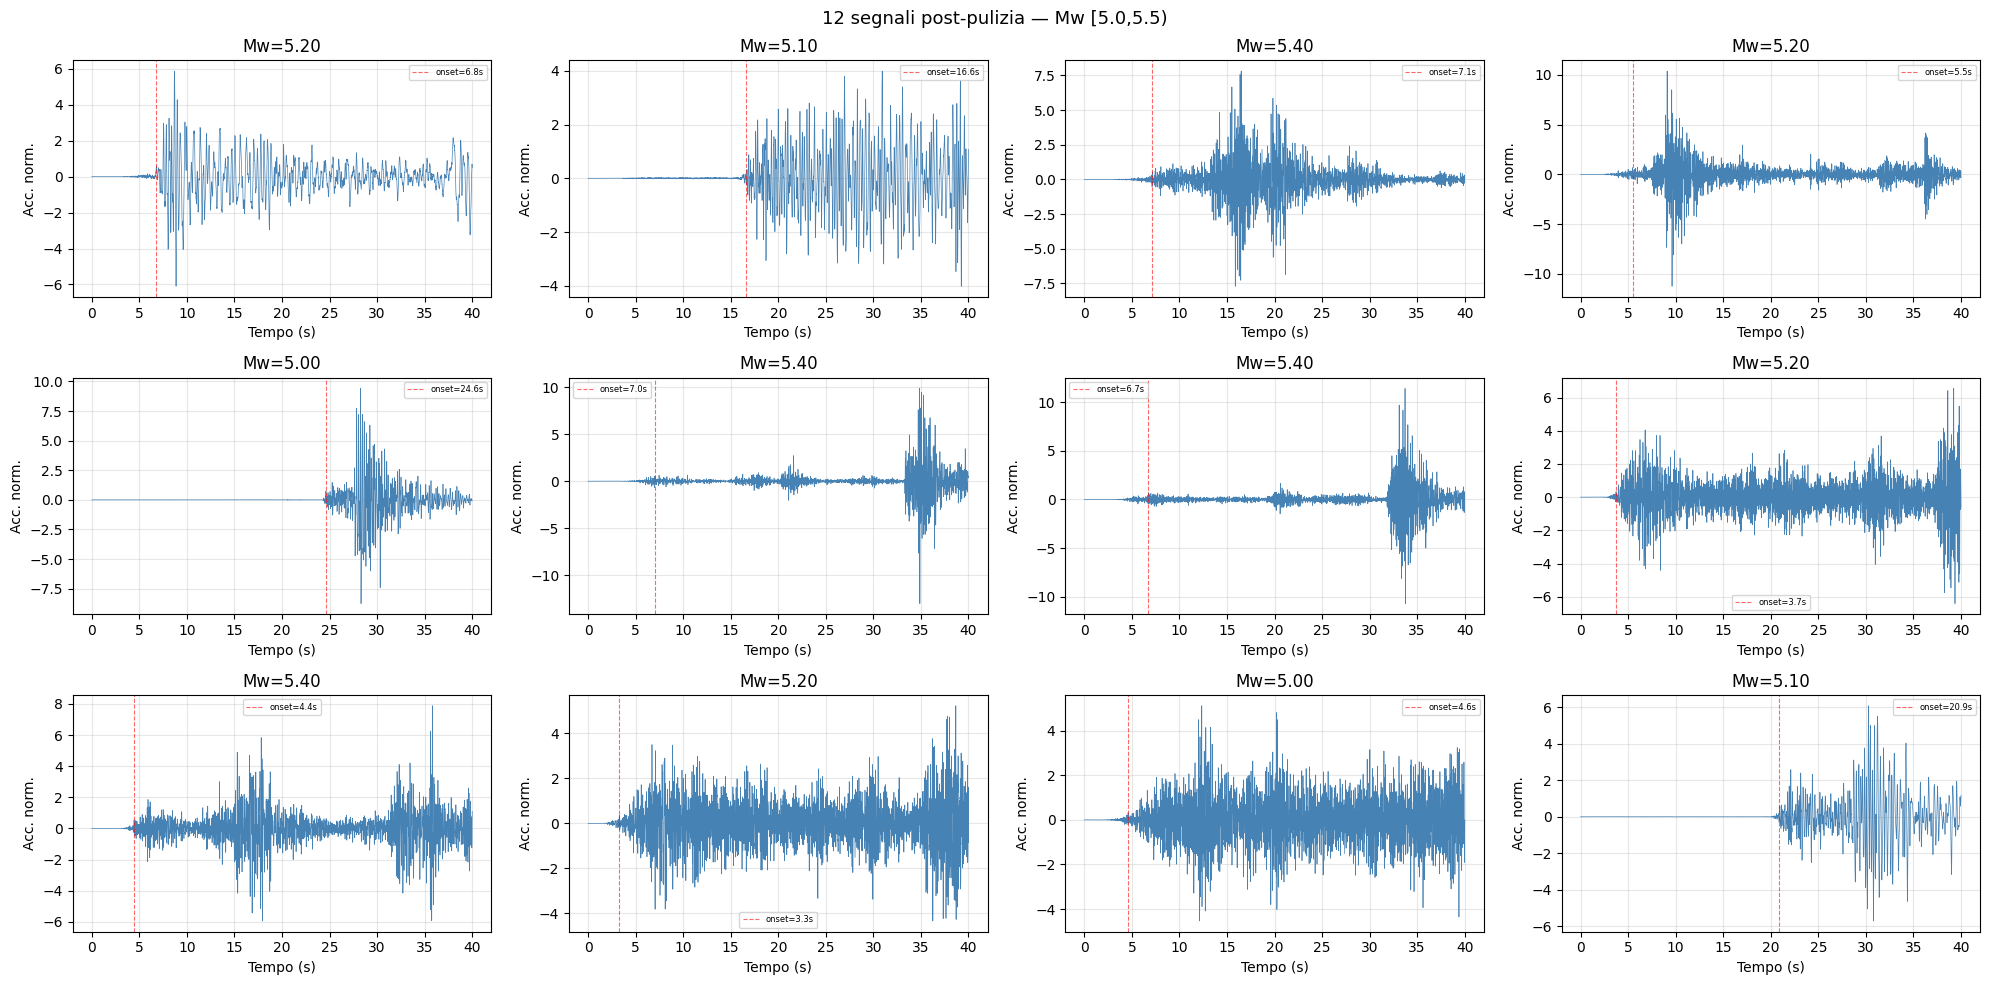

In [11]:
# ── Verifica visiva post-pulizia ──────────────────────────────────────────────
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(HDF5_PATH, 'r') as hf:
    sigs = hf['signals_e'][:12]
    mags = hf['magnitudes'][:12]

t = np.linspace(0, DURATION_S, N_SAMPLES)
fig, axes = plt.subplots(3, 4, figsize=(20, 10))

for ax, sig, mw in zip(axes.flatten(), sigs, mags):
    ax.plot(t, sig, linewidth=0.5, color='steelblue')
    ax.set_title(f'Mw={mw:.2f}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Acc. norm.')
    ax.grid(alpha=0.3)
    thr = 0.05 * np.max(np.abs(sig))
    idx = np.where(np.abs(sig) > thr)[0]
    if len(idx) > 0:
        onset_s = idx[0] / 200.0
        ax.axvline(onset_s, color='red', linestyle='--',
                   alpha=0.6, linewidth=0.8, label=f'onset={onset_s:.1f}s')
        ax.legend(fontsize=6)

plt.suptitle(f'12 segnali post-pulizia — Mw [{MW_MIN},{MW_MAX})', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'verifica_post_pulizia.png'), dpi=150)
plt.show()

In [13]:
# record rimasti dopo la pulizia
#
with h5py.File(HDF5_PATH, 'r') as hf:
    print(f'Record validi: {hf.attrs["total_records"]}')

Record validi: 1879
